# Weighted Least Squares -- RMST

**This notebook fits weighted least squares regression models to predict RMST pseudo-observations at 1 and 2 years. The model uses gradient boosted survival model predictions at 6 months from first-line treatment for advanced non-small cell lung cancer. Observations are weighted using overlap weights.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
from statsmodels.formula.api import wls
import matplotlib.pyplot as plt

from iptw_survival import OverlapWeightSurvivalEstimator

from utils.treatment_effects import calculate_treatment_effect_curve_rmst

## Import data 

### Import calibrated survival probabilities 

In [2]:
surv_pred_df = pd.read_csv('../outputs/gb_6m_survival_predictions_calibrated.csv')

In [3]:
surv_pred_df.head(3)

,PatientID,psurv_180_calibrated
0,FF16F972863F8,0.478161
1,F5EF114860555,0.596677
2,F95B93B796545,0.935103


In [4]:
surv_pred_df.shape

(1681, 2)

### Import treatment assignment

In [5]:
treatment_df = pd.read_csv('../outputs/pembrochemo_pembro_index.csv')

In [6]:
treatment_df.shape

(20623, 3)

In [7]:
treatment_df.head(3)

,PatientID,LineName,StartDate
0,FA2BFA6104994,pembro_platinum,2019-08-19
1,F40B0A967B8AC,pembro_platinum,2020-03-13
2,F242D29EFD1F3,pembro_platinum,2024-03-08


### Import features

In [8]:
dtype_map = pd.read_csv('../outputs/pembrochemo_pembro_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
features_df = pd.read_csv('../outputs/pembrochemo_pembro_features_df.csv', dtype = dtype_map)

In [9]:
features_df.shape

(2064, 164)

### Import RMST pseudo-observations

In [10]:
pseudo_obs_df = pd.read_csv('../outputs/pseudo_obs_rmst.csv')

In [11]:
pseudo_obs_df.shape

(1681, 3)

In [12]:
pseudo_obs_df.head(3)

,PatientID,rmst_pseudo_1y,rmst_pseudo_2y
0,FF16F972863F8,299.446640,283.129363
1,F5EF114860555,159.475543,149.676630
2,F95B93B796545,368.006492,743.998856


### Merge dataframes

In [13]:
df = pd.merge(features_df, surv_pred_df, on = 'PatientID', how = 'left')

In [14]:
df.shape

(2064, 165)

In [15]:
df = pd.merge(df, pseudo_obs_df, on = 'PatientID', how = 'left')

In [16]:
df.shape

(2064, 167)

In [17]:
df = pd.merge(df, treatment_df, on = 'PatientID', how = 'left')

In [18]:
df.shape

(2064, 169)

In [19]:
df = df.query('adv_diagnosis_year <= 2023')

In [20]:
df.shape

(1681, 169)

## Calculating overlap weights

In [21]:
df['treatment'] = np.where(df['LineName'] == 'pembro_platinum', 1, 0)

In [22]:
df.treatment.value_counts()

treatment
0    1096
1     585
Name: count, dtype: int64

In [23]:
estimator = OverlapWeightSurvivalEstimator(normalize = None)

In [24]:
estimator.fit(df = df,
              treatment_col = 'treatment',
              cat_var = ['Histology', 'SmokingStatus'],
              cont_var = ['days_diagnosis_to_adv', 'GroupStage_mod', 'ecog_index', 'ses_mod', 'age', 'percent_change_weight', 'hemoglobin', 'albumin', 'total_bilirubin', 'creatinine', 'van_walraven_score'],
              binary_var = ['sex_male', 'ecog_index_na', 'ses_mod_na', 'medicaid', 'before_2020', 'days_to_treatment_before_30d'],
              lr_kwargs = {
                  'class_weight': 'balanced',
                  'solver': 'lbfgs',
                  'penalty': 'l2',
                  'max_iter': 1000,
                  'random_state': 42
              },
              clip_bounds = (0.01, 0.99),
              stabilized = False,
              use_missing_flags = False)

In [25]:
overlap_df = estimator.transform()

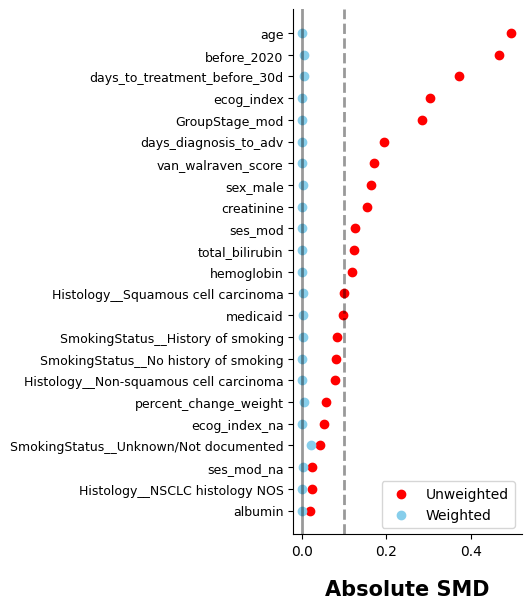

In [26]:
_, smd_fig = estimator.standardized_mean_differences(return_fig = True)

ax = smd_fig.axes[0]

# Resize figure
smd_fig.set_size_inches(4, 6)

# Axis/title font sizes
ax.set_xlabel('Absolute SMD', fontsize=15)
ax.set_title('')

# Reference line styles
for line in ax.lines:
    line.set_alpha(0.4)

ax.tick_params(axis='y', labelsize=9)
ax.legend(prop={'size': 10})
smd_fig.savefig('../outputs/smd_plot_wls.pdf', dpi=300, bbox_inches='tight')
smd_fig

## WLS model

In [27]:
# Create grid of psurv_180 values (5th to 95th percentile)
psurv_grid = np.linspace(
    overlap_df['psurv_180_calibrated'].quantile(0.05),
    overlap_df['psurv_180_calibrated'].quantile(0.95),
    200
)

In [28]:
formula_1y = 'rmst_pseudo_1y ~ treatment * psurv_180_calibrated'

model_1y = wls(
    formula = formula_1y,
    data = overlap_df,
    weights = overlap_df['overlap_weight']
).fit(cov_type = 'HC3')

print(model_1y.summary())

                            WLS Regression Results                            
Dep. Variable:         rmst_pseudo_1y   R-squared:                       0.185
Model:                            WLS   Adj. R-squared:                  0.184
Method:                 Least Squares   F-statistic:                     103.4
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           1.99e-61
Time:                        04:44:04   Log-Likelihood:                -10537.
No. Observations:                1681   AIC:                         2.108e+04
Df Residuals:                    1677   BIC:                         2.110e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

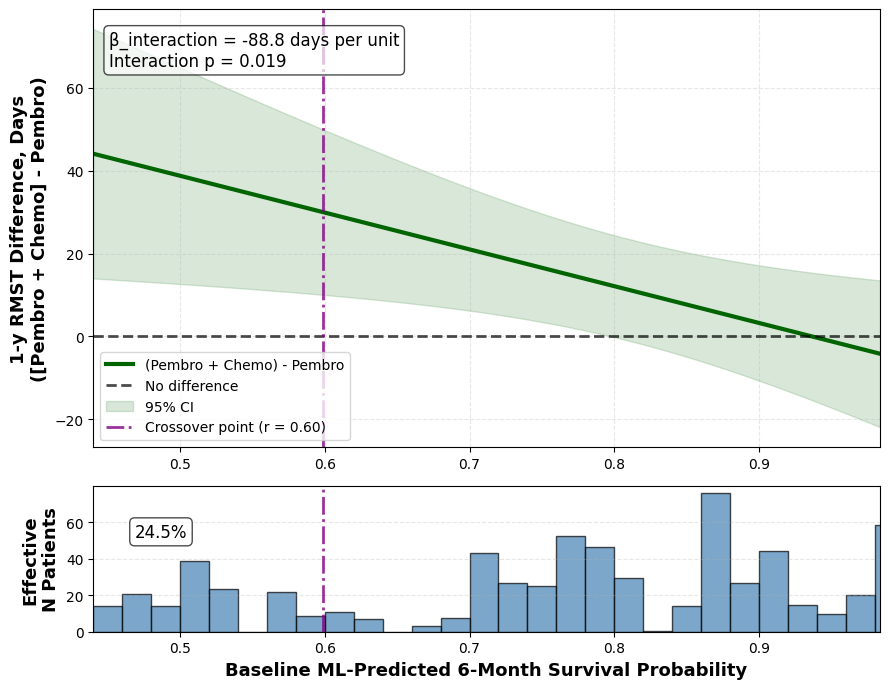

In [29]:
# Calculate treatment effects using the utils function
effect_1y_df = calculate_treatment_effect_curve_rmst(
    model = model_1y,
    baseline_var = 'psurv_180_calibrated',
    baseline_values = psurv_grid
)

# Plot treatment effect
fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (9, 7), gridspec_kw = {'height_ratios': [3, 1]})

ax1.plot(effect_1y_df['baseline'], effect_1y_df['treatment_effect'], 
         linewidth = 3, color = 'darkgreen', label = '(Pembro + Chemo) - Pembro')

ax1.axhline(y = 0, color = 'black', linestyle = '--', linewidth = 2, alpha = 0.7, label = 'No difference')

# Shade 95% CI
ax1.fill_between(effect_1y_df['baseline'], effect_1y_df['ci_lower'], effect_1y_df['ci_upper'], 
                 alpha = 0.15, color = 'darkgreen', label = '95% CI')

# Define crossover value 
crossover_value = 30  

# Calculate crossover point algebraically: TE(r) = beta1 + beta3*r = crossover_value
# Solving for r: r = (crossover_value - beta1) / beta3
beta1 = model_1y.params['treatment']
beta3 = model_1y.params['treatment:psurv_180_calibrated']
crossover_survival_estimate = (crossover_value - beta1) / beta3

# Check if crossover point is within the observed data range
crossover_in_range = (crossover_survival_estimate >= psurv_grid.min()) and (crossover_survival_estimate <= psurv_grid.max())

# Add vertical line at crossover point if it's in range
if crossover_in_range:
    ax1.axvline(x = crossover_survival_estimate, color = 'purple', alpha = 0.8, linestyle = '-.', linewidth = 2, 
               label = f'Crossover point (r = {crossover_survival_estimate:.2f})')

ax1.set_ylabel('1-y RMST Difference, Days\n([Pembro + Chemo] - Pembro)', fontsize = 13, fontweight = 'bold')

ax1.legend(fontsize = 10, loc = 'lower left')
ax1.grid(alpha = 0.3, linestyle = '--')
ax1.set_xlim([psurv_grid.min(), psurv_grid.max()])

# Extract key stats
interaction_coef = model_1y.params['treatment:psurv_180_calibrated']
interaction_pval = model_1y.pvalues['treatment:psurv_180_calibrated']

# Add text box to plot
stats_text = f'β_interaction = {interaction_coef:.1f} days per unit\n'
stats_text += f'Interaction p = {interaction_pval:.3f}'

ax1.text(0.02, 0.95, stats_text,
         transform = ax1.transAxes,
         fontsize = 12,
         verticalalignment = 'top',
         horizontalalignment = 'left',
         bbox = dict(boxstyle = 'round', facecolor ='white', alpha = 0.7))

# Bottom panel
ax2.hist(overlap_df['psurv_180_calibrated'], 
         bins = 50,
         weights = overlap_df['overlap_weight'],
         alpha = 0.7, 
         edgecolor = 'black', 
         color = 'steelblue')

# Add crossover line to bottom panel if in range
if crossover_in_range:
    ax2.axvline(x = crossover_survival_estimate, color = 'purple', alpha = 0.8, linestyle = '-.', linewidth = 2)
    
    # Calculate weighted percentile below crossover
    weighted_pct_below = (
        overlap_df.loc[overlap_df['psurv_180_calibrated'] <= crossover_survival_estimate, 'overlap_weight'].sum() / 
        overlap_df['overlap_weight'].sum() * 100
    )
    
    # Add percentile annotation
    ax2.text(crossover_survival_estimate - 0.13, ax2.get_ylim()[1]*0.65, 
             f"{weighted_pct_below:.1f}%", 
             ha = 'left', fontsize = 12,
             bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.7))

ax2.set_xlabel('Baseline ML-Predicted 6-Month Survival Probability', fontsize = 13, fontweight = 'bold')
ax2.set_ylabel('Effective\nN Patients', fontsize = 13, fontweight = 'bold')
ax2.set_xlim([psurv_grid.min(), psurv_grid.max()])
ax2.grid(alpha = 0.3, linestyle = '--', axis = 'y')

plt.tight_layout()
#plt.savefig('../outputs/wls_rmst_1y.pdf', format = 'pdf', bbox_inches = 'tight')
plt.show()

In [30]:
formula_2y = 'rmst_pseudo_2y ~ treatment * psurv_180_calibrated'

model_2y = wls(
    formula = formula_2y,
    data = overlap_df,
    weights = overlap_df['overlap_weight']
).fit(cov_type = 'HC3')

print(model_2y.summary())

                            WLS Regression Results                            
Dep. Variable:         rmst_pseudo_2y   R-squared:                       0.198
Model:                            WLS   Adj. R-squared:                  0.196
Method:                 Least Squares   F-statistic:                     128.2
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           9.69e-75
Time:                        04:44:04   Log-Likelihood:                -11849.
No. Observations:                1681   AIC:                         2.371e+04
Df Residuals:                    1677   BIC:                         2.373e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

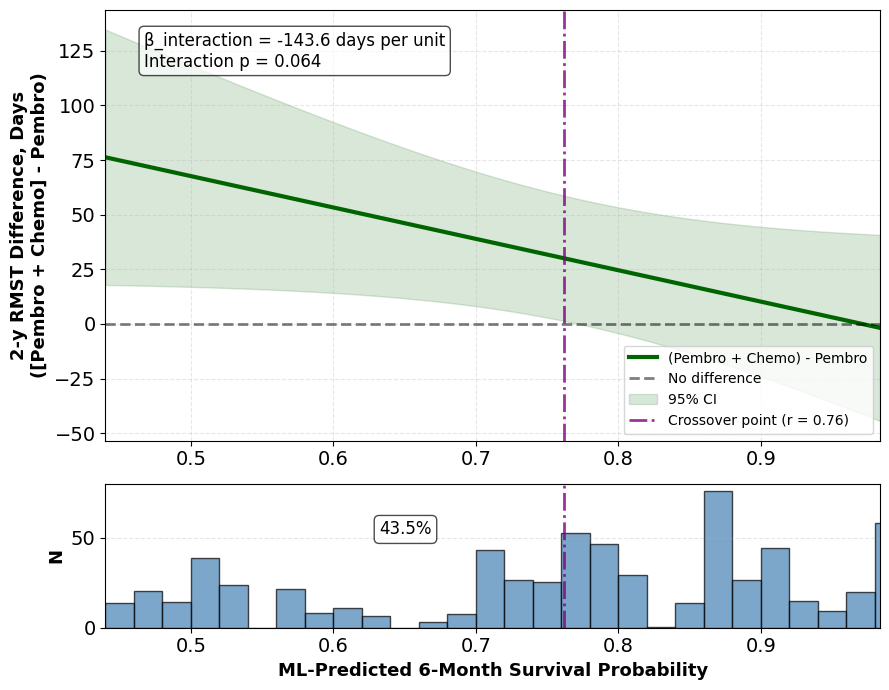

In [31]:
# Calculate treatment effects using the utils function
effect_2y_df = calculate_treatment_effect_curve_rmst(
    model = model_2y,
    baseline_var = 'psurv_180_calibrated',
    baseline_values = psurv_grid
)

# Plot treatment effect
fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (9, 7), gridspec_kw = {'height_ratios': [3, 1]})

ax1.plot(effect_2y_df['baseline'], effect_2y_df['treatment_effect'], 
         linewidth = 3, color = 'darkgreen', label = '(Pembro + Chemo) - Pembro')

ax1.axhline(y = 0, color = 'black', linestyle = '--', linewidth = 2, alpha = 0.5, label = 'No difference')
#ax1.axhline(y = 30, color = 'black', linestyle = '-.', linewidth = 2, alpha = 0.5, label = '30d')

# Shade 95% CI
ax1.fill_between(effect_2y_df['baseline'], effect_2y_df['ci_lower'], effect_2y_df['ci_upper'], 
                 alpha = 0.15, color = 'darkgreen', label = '95% CI')

# Define crossover value 
crossover_value = 30  

# Calculate crossover point algebraically: TE(r) = beta1 + beta3*r = crossover_value
# Solving for r: r = (crossover_value - beta1) / beta3
beta1 = model_2y.params['treatment']
beta3 = model_2y.params['treatment:psurv_180_calibrated']
crossover_survival_estimate = (crossover_value - beta1) / beta3

# Check if crossover point is within the observed data range
crossover_in_range = (crossover_survival_estimate >= psurv_grid.min()) and (crossover_survival_estimate <= psurv_grid.max())

# Add vertical line at crossover point if it's in range
if crossover_in_range:
    ax1.axvline(x = crossover_survival_estimate, color = 'purple', alpha = 0.8, linestyle = '-.', linewidth = 2, 
               label = f'Crossover point (r = {crossover_survival_estimate:.2f})')

ax1.set_ylabel('2-y RMST Difference, Days\n([Pembro + Chemo] - Pembro)', fontsize = 13, fontweight = 'bold')

ax1.legend(fontsize = 10, loc = 'lower right')
ax1.grid(alpha = 0.3, linestyle = '--')
ax1.set_xlim([psurv_grid.min(), psurv_grid.max()])
ax1.tick_params(axis='both', labelsize=14)

# Extract key stats
interaction_coef = model_2y.params['treatment:psurv_180_calibrated']
interaction_pval = model_2y.pvalues['treatment:psurv_180_calibrated']

# Format p-value for display
if interaction_pval < 0.001:
    pval_text = '<0.001'
else:
    pval_text = f'{interaction_pval:.3f}'

# Add text box to plot
stats_text = f'β_interaction = {interaction_coef:.1f} days per unit\n'
stats_text += f'Interaction p = {pval_text}'

ax1.text(0.05, 0.95, stats_text,
         transform = ax1.transAxes,
         fontsize = 12,
         verticalalignment = 'top',
         horizontalalignment = 'left',
         bbox = dict(boxstyle = 'round', facecolor ='white', alpha = 0.7))

# Bottom panel
ax2.hist(overlap_df['psurv_180_calibrated'], 
         bins = 50,
         weights = overlap_df['overlap_weight'],
         alpha = 0.7, 
         edgecolor = 'black', 
         color = 'steelblue')

# Add crossover line to bottom panel if in range
if crossover_in_range:
    ax2.axvline(x = crossover_survival_estimate, color = 'purple', alpha = 0.8, linestyle = '-.', linewidth = 2)
    
    # Calculate weighted percentile below crossover
    weighted_pct_below = (
        overlap_df.loc[overlap_df['psurv_180_calibrated'] <= crossover_survival_estimate, 'overlap_weight'].sum() / 
        overlap_df['overlap_weight'].sum() * 100
    )
    
    # Add percentile annotation
    ax2.text(crossover_survival_estimate - 0.13, ax2.get_ylim()[1]*0.65, 
             f"{weighted_pct_below:.1f}%", 
             ha = 'left', fontsize = 12,
             bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.7))

ax2.set_xlabel('ML-Predicted 6-Month Survival Probability', fontsize = 13, fontweight = 'bold')
ax2.set_ylabel('N', fontsize = 13, fontweight = 'bold')
ax2.set_xlim([psurv_grid.min(), psurv_grid.max()])
ax2.grid(alpha = 0.3, linestyle = '--', axis = 'y')
ax2.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig('../outputs/wls_rmst_2y.pdf', format = 'pdf', bbox_inches = 'tight')
plt.show()

# Save 30d crossover survival estimate
with open('../outputs/crossover_survival_estimate.txt', 'w') as f:
    f.write(str(crossover_survival_estimate))

# Save 0d crossover survival estimate for sensivity analysis
crossover_survival_estimate_0d = (0 - beta1) / beta3
with open('../outputs/crossover_survival_estimate_0d.txt', 'w') as f:
    f.write(str(crossover_survival_estimate_0d))